In [2]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [3]:
import torch

# Check GPU is available
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

sam2_model = build_sam2(
    config_file="configs/sam2.1/sam2.1_hiera_l.yaml",
    ckpt_path="checkpoints/sam2.1_hiera_large.pt",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

predictor = SAM2ImagePredictor(sam2_model)
print("Model loaded successfully!")

CUDA available: True
Device: Tesla T4
Model loaded successfully!


In [4]:
device = torch.device("cuda")

In [25]:
import json
import numpy as np
from PIL import Image
from shapely import wkt
import os

DATA_DIR = "/home/sagemaker-user/42028-DLCNN/data/xbd/train"

def load_sample(disaster_name, sample_id, data_dir=DATA_DIR):
    base = f"{disaster_name}_{sample_id:08d}"
    pre_img  = np.array(Image.open(f"{data_dir}/images/{base}_pre_disaster.png").convert("RGB"))
    post_img = np.array(Image.open(f"{data_dir}/images/{base}_post_disaster.png").convert("RGB"))
    
    with open(f"{data_dir}/labels/{base}_post_disaster.json") as f:
        label = json.load(f)
    
    buildings = []
    for feature in label["features"]["xy"]:
        poly = wkt.loads(feature["wkt"])
        damage = feature["properties"]["subtype"]
        coords = np.array(poly.exterior.coords, dtype=np.int32)
        buildings.append({"polygon": coords, "damage": damage})
    
    return pre_img, post_img, buildings

# Test it
pre, post, buildings = load_sample("guatemala-volcano", 0)
print(f"Pre image shape:  {pre.shape}")
print(f"Post image shape: {post.shape}")
print(f"Buildings found:  {len(buildings)}")
print(f"First building:   {buildings[0]}")

Pre image shape:  (1024, 1024, 3)
Post image shape: (1024, 1024, 3)
Buildings found:  10
First building:   {'polygon': array([[532, 165],
       [548, 224],
       [446, 264],
       [440, 249],
       [425, 253],
       [420, 232],
       [437, 227],
       [431, 201],
       [532, 165]], dtype=int32), 'damage': 'no-damage'}


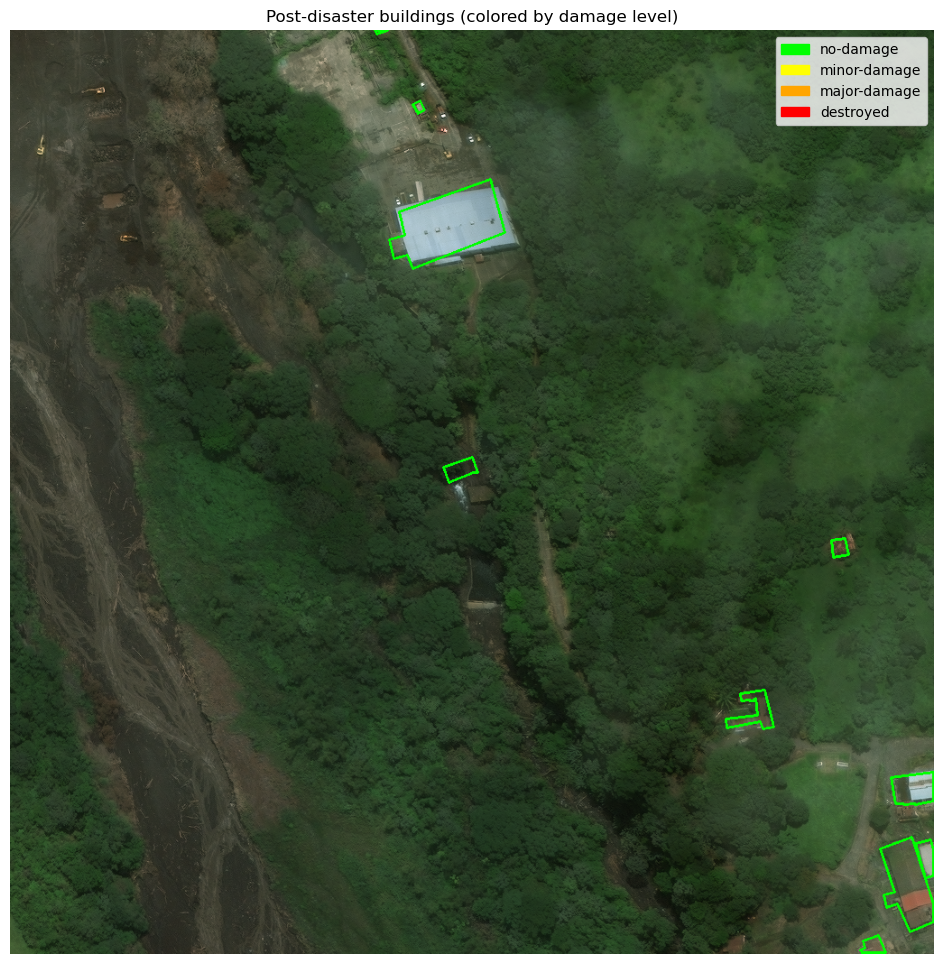

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

DAMAGE_COLORS = {
    "no-damage":    (0, 255, 0),    # green
    "minor-damage": (255, 255, 0),  # yellow
    "major-damage": (255, 165, 0),  # orange
    "destroyed":    (255, 0, 0),    # red
}

def visualize_sample(post_img, buildings):
    vis = post_img.copy()
    for b in buildings:
        color = DAMAGE_COLORS.get(b["damage"], (255, 255, 255))
        cv2.polylines(vis, [b["polygon"]], isClosed=True, color=color, thickness=2)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(vis)
    plt.title("Post-disaster buildings (colored by damage level)")
    plt.axis("off")
    
    # legend
    patches = [mpatches.Patch(color=np.array(c)/255, label=k) for k, c in DAMAGE_COLORS.items()]
    plt.legend(handles=patches, loc="upper right")
    plt.show()

visualize_sample(post, buildings)

In [9]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import torch

def get_bbox(polygon):
    """Get bounding box [x0, y0, x1, y1] from polygon coords."""
    x0, y0 = polygon[:, 0].min(), polygon[:, 1].min()
    x1, y1 = polygon[:, 0].max(), polygon[:, 1].max()
    return np.array([x0, y0, x1, y1])

# Set image for SAM2
predictor.set_image(post)

# Run SAM2 on each building
results = []
for b in buildings:
    bbox = get_bbox(b["polygon"])
    
    masks, scores, _ = predictor.predict(
        box=bbox,
        multimask_output=False  # one mask per building
    )
    
    results.append({
        "mask":   masks[0],       # (1024, 1024) boolean array
        "score":  scores[0],
        "damage": b["damage"],
        "bbox":   bbox
    })

print(f"Segmented {len(results)} buildings")
print(f"Example — damage: {results[0]['damage']}, score: {results[0]['score']:.3f}, mask sum: {results[0]['mask'].sum()}")

Segmented 10 buildings
Example — damage: no-damage, score: 0.966, mask sum: 8349.0


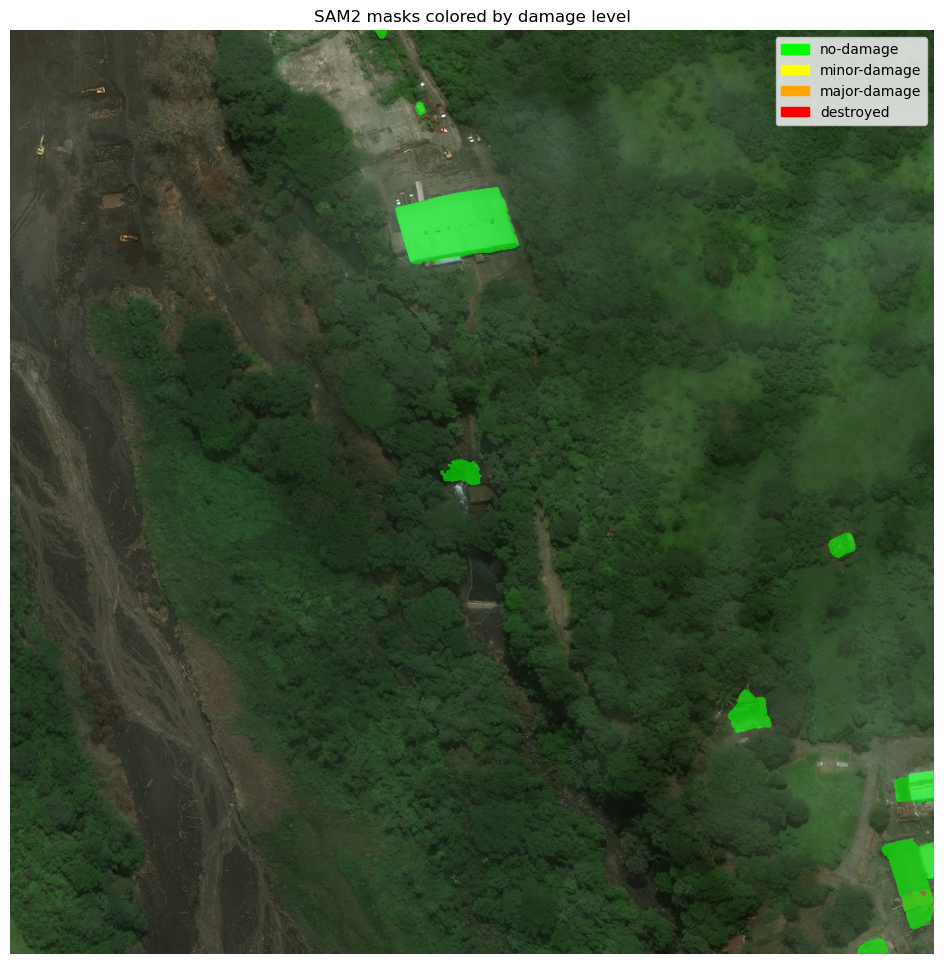

In [10]:
def visualize_masks(post_img, results):
    vis = post_img.copy().astype(np.float32)
    
    for r in results:
        color = np.array(DAMAGE_COLORS[r["damage"]], dtype=np.float32)
        mask = r["mask"].astype(bool)
        vis[mask] = vis[mask] * 0.4 + color * 0.6
    
    vis = vis.astype(np.uint8)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(vis)
    plt.title("SAM2 masks colored by damage level")
    plt.axis("off")
    patches = [mpatches.Patch(color=np.array(c)/255, label=k) for k, c in DAMAGE_COLORS.items()]
    plt.legend(handles=patches, loc="upper right")
    plt.show()

visualize_masks(post, results)

In [11]:
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

CROP_SIZE = 128

transform = T.Compose([
    T.Resize((CROP_SIZE, CROP_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def extract_crop(image, bbox):
    """Crop a building region from an image using its bounding box."""
    x0, y0, x1, y1 = bbox.astype(int)
    pad = 10
    x0, y0 = max(0, x0 - pad), max(0, y0 - pad)
    x1, y1 = min(image.shape[1], x1 + pad), min(image.shape[0], y1 + pad)
    crop = image[y0:y1, x0:x1]
    return transform(Image.fromarray(crop))

# Test on first building
r = results[0]
pre_crop  = extract_crop(pre, r["bbox"])
post_crop = extract_crop(post, r["bbox"])
print(f"Pre crop shape:  {pre_crop.shape}")
print(f"Post crop shape: {post_crop.shape}")
print(f"Damage label:    {r['damage']}")

Pre crop shape:  torch.Size([3, 128, 128])
Post crop shape: torch.Size([3, 128, 128])
Damage label:    no-damage


In [12]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

DAMAGE_CLASSES = ["no-damage", "minor-damage", "major-damage", "destroyed"]
NUM_CLASSES = len(DAMAGE_CLASSES)

class DamageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # shared ResNet18 backbone for both pre and post crops
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        # remove final classification layer, keep feature extractor
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])  # output: (batch, 512, 1, 1)
        
        # classifier takes concatenated pre+post features
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )
    
    def forward(self, pre, post):
        pre_feat  = self.encoder(pre).flatten(1)   # (batch, 512)
        post_feat = self.encoder(post).flatten(1)  # (batch, 512)
        combined  = torch.cat([pre_feat, post_feat], dim=1)  # (batch, 1024)
        return self.classifier(combined)

# test forward pass
model = DamageClassifier().to(device)
pre_batch  = pre_crop.unsqueeze(0).to(device)
post_batch = post_crop.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(pre_batch, post_batch)

print(f"Output shape: {logits.shape}")
print(f"Predicted class: {DAMAGE_CLASSES[logits.argmax().item()]}")
print("Model ready!")

Output shape: torch.Size([1, 4])
Predicted class: no-damage
Model ready!


In [13]:
from torch.utils.data import Dataset, DataLoader
import glob

class XBDDataset(Dataset):
    def __init__(self, data_dir, predictor):
        self.data_dir = data_dir
        self.predictor = predictor
        self.samples = []  # list of (pre_img, post_img, bbox, damage_label)
        self._build_samples()
    
    def _build_samples(self):
        label_files = glob.glob(f"{self.data_dir}/labels/*_post_disaster.json")
        print(f"Found {len(label_files)} post-disaster label files")
        
        for label_path in label_files:
            base = os.path.basename(label_path).replace("_post_disaster.json", "")
            pre_path  = f"{self.data_dir}/images/{base}_pre_disaster.png"
            post_path = f"{self.data_dir}/images/{base}_post_disaster.png"
            
            if not os.path.exists(pre_path) or not os.path.exists(post_path):
                continue
            
            with open(label_path) as f:
                label = json.load(f)
            
            for feature in label["features"]["xy"]:
                damage = feature["properties"]["subtype"]
                if damage not in DAMAGE_CLASSES:
                    continue
                poly = wkt.loads(feature["wkt"])
                coords = np.array(poly.exterior.coords, dtype=np.int32)
                bbox = get_bbox(coords)
                # skip tiny buildings
                if (bbox[2]-bbox[0]) < 5 or (bbox[3]-bbox[1]) < 5:
                    continue
                self.samples.append((pre_path, post_path, bbox, damage))
        
        print(f"Total buildings: {len(self.samples)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        pre_path, post_path, bbox, damage = self.samples[idx]
        pre_img  = np.array(Image.open(pre_path).convert("RGB"))
        post_img = np.array(Image.open(post_path).convert("RGB"))
        pre_crop  = extract_crop(pre_img, bbox)
        post_crop = extract_crop(post_img, bbox)
        label = DAMAGE_CLASSES.index(damage)
        return pre_crop, post_crop, label

# build dataset
dataset = XBDDataset(DATA_DIR, predictor)

# split 80/20 train/val
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Found 2799 post-disaster label files
Total buildings: 159233
Train: 127386 | Val: 31847


In [14]:
def get_class_weights_fast(data_dir):
    counts = [0] * NUM_CLASSES
    label_files = glob.glob(f"{data_dir}/labels/*_post_disaster.json")
    
    for label_path in label_files:
        with open(label_path) as f:
            label = json.load(f)
        for feature in label["features"]["xy"]:
            damage = feature["properties"]["subtype"]
            if damage in DAMAGE_CLASSES:
                counts[DAMAGE_CLASSES.index(damage)] += 1
    
    total = sum(counts)
    weights = [total / (NUM_CLASSES * c) for c in counts]
    print(f"Class counts:  {dict(zip(DAMAGE_CLASSES, counts))}")
    print(f"Class weights: {dict(zip(DAMAGE_CLASSES, [round(w,2) for w in weights]))}")
    return torch.tensor(weights, dtype=torch.float).to(device)

print("Computing class weights...")
weights = get_class_weights_fast(DATA_DIR)

Computing class weights...
Class counts:  {'no-damage': 117426, 'minor-damage': 14980, 'major-damage': 14161, 'destroyed': 13227}
Class weights: {'no-damage': 0.34, 'minor-damage': 2.67, 'major-damage': 2.82, 'destroyed': 3.02}


In [15]:
import os
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

# define optimizer and scheduler first
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

# then resume checkpoint
checkpoint_dir = "/home/sagemaker-user/42028-DLCNN/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
latest_checkpoint = f"{checkpoint_dir}/checkpoint_latest.pt"

start_epoch = 0
best_val_acc = 0

if os.path.exists(latest_checkpoint):
    print("Found checkpoint, resuming training...")
    checkpoint = torch.load(latest_checkpoint)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"]
    best_val_acc = checkpoint["best_val_acc"]
    print(f"Resumed from epoch {start_epoch}, best val acc so far: {best_val_acc:.4f}")
else:
    print("No checkpoint found, starting fresh")

Found checkpoint, resuming training...
Resumed from epoch 10, best val acc so far: 0.8840


In [29]:
import time

import glob

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

def train_epoch(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss, correct, total = 0, 0, 0
    start = time.time()
    num_batches = len(loader)

    for batch_idx, (pre, post, labels) in enumerate(loader):
        pre, post, labels = pre.to(device), post.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(pre, post)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (logits.argmax(1) == labels).sum().item()
        total += len(labels)

        # print every 50 batches
        if (batch_idx + 1) % 50 == 0 or (batch_idx + 1) == num_batches:
            elapsed = time.time() - start
            batches_done = batch_idx + 1
            eta = (elapsed / batches_done) * (num_batches - batches_done)
            print(f"  Epoch {epoch+1} | batch {batches_done}/{num_batches} | "
                  f"loss: {loss.item():.4f} | "
                  f"acc: {correct/total:.4f} | "
                  f"elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")

    return total_loss / num_batches, correct / total

def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    start = time.time()
    num_batches = len(loader)

    with torch.no_grad():
        for batch_idx, (pre, post, labels) in enumerate(loader):
            pre, post, labels = pre.to(device), post.to(device), labels.to(device)
            logits = model(pre, post)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += len(labels)

            if (batch_idx + 1) % 50 == 0 or (batch_idx + 1) == num_batches:
                elapsed = time.time() - start
                print(f"  Val | batch {batch_idx+1}/{num_batches} | "
                      f"loss: {loss.item():.4f} | "
                      f"acc: {correct/total:.4f} | "
                      f"elapsed: {elapsed:.0f}s")

    return total_loss / num_batches, correct / total

# training loop
NUM_EPOCHS = 10
best_val_acc = 0

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} starting...")
    print(f"{'='*60}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, epoch)
    val_loss, val_acc     = val_epoch(model, val_loader, criterion)
    scheduler.step()
    epoch_time = time.time() - epoch_start

    print(f"\nEpoch {epoch+1} summary | "
          f"train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"time: {epoch_time:.0f}s")

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_acc": best_val_acc,
    }, latest_checkpoint)
    print(f"  -> Saved checkpoint (epoch {epoch+1})")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/home/sagemaker-user/42028-DLCNN/checkpoints/best_model.pt")
        print(f"  -> Saved best model (val acc: {val_acc:.4f})")

Computing class weights...
Class counts:  {'no-damage': 117426, 'minor-damage': 14980, 'major-damage': 14161, 'destroyed': 13227}
Class weights: {'no-damage': 0.34, 'minor-damage': 2.67, 'major-damage': 2.82, 'destroyed': 3.02}

Epoch 8/10 starting...
  Epoch 8 | batch 50/3981 | loss: 0.0167 | acc: 0.9350 | elapsed: 48s | ETA: 3796s
  Epoch 8 | batch 100/3981 | loss: 0.4844 | acc: 0.9272 | elapsed: 93s | ETA: 3600s
  Epoch 8 | batch 150/3981 | loss: 0.4229 | acc: 0.9263 | elapsed: 141s | ETA: 3598s
  Epoch 8 | batch 200/3981 | loss: 0.1175 | acc: 0.9247 | elapsed: 185s | ETA: 3493s
  Epoch 8 | batch 250/3981 | loss: 0.1912 | acc: 0.9221 | elapsed: 234s | ETA: 3496s
  Epoch 8 | batch 300/3981 | loss: 0.3253 | acc: 0.9197 | elapsed: 278s | ETA: 3416s
  Epoch 8 | batch 350/3981 | loss: 0.0796 | acc: 0.9195 | elapsed: 326s | ETA: 3382s
  Epoch 8 | batch 400/3981 | loss: 0.2137 | acc: 0.9191 | elapsed: 371s | ETA: 3321s
  Epoch 8 | batch 450/3981 | loss: 0.4837 | acc: 0.9183 | elapsed: 418s

              precision    recall  f1-score   support

   no-damage       0.99      0.89      0.94     23355
minor-damage       0.61      0.94      0.74      2917
major-damage       0.83      0.94      0.88      2897
   destroyed       0.84      0.97      0.90      2678

    accuracy                           0.91     31847
   macro avg       0.82      0.94      0.87     31847
weighted avg       0.93      0.91      0.91     31847



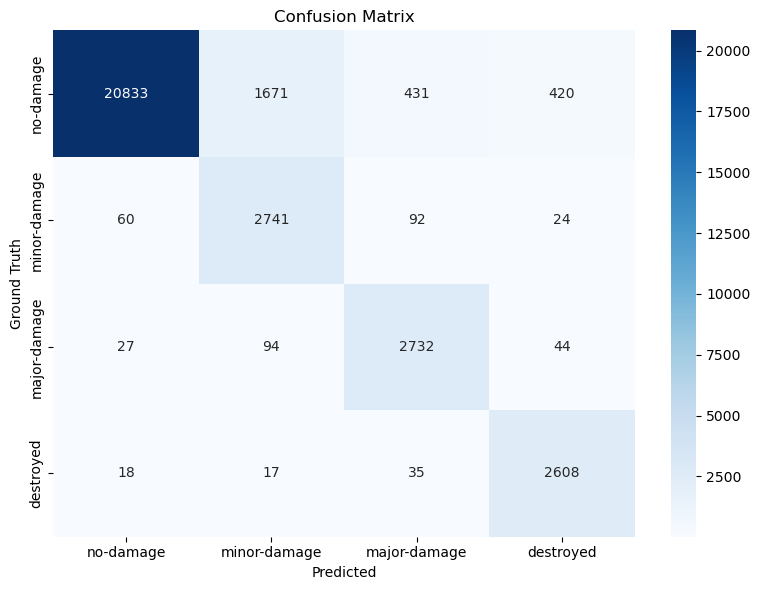

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for pre, post, labels in val_loader:
        pre, post = pre.to(device), post.to(device)
        logits = model(pre, post)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# classification report
print(classification_report(all_labels, all_preds, target_names=DAMAGE_CLASSES))

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", 
            xticklabels=DAMAGE_CLASSES, 
            yticklabels=DAMAGE_CLASSES,
            cmap="Blues")
plt.ylabel("Ground Truth")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
import random
       
def find_diverse_sample(data_dir, target_damages=["minor-damage", "major-damage", "destroyed"]):
    """Find a scene that contains damaged buildings."""
    label_files = glob.glob(f"{data_dir}/labels/*_post_disaster.json")
    random.shuffle(label_files)
    
    for label_path in label_files:
        with open(label_path) as f:
            label = json.load(f)
        
        damages = [f["properties"]["subtype"] for f in label["features"]["xy"]]
        
        # check if this scene has at least one of the target damage types
        if any(d in damages for d in target_damages):
            base = os.path.basename(label_path).replace("_post_disaster.json", "")
            disaster, sample_id = "_".join(base.split("_")[:-1]), int(base.split("_")[-1])
            print(f"Found: {base}")
            print(f"Damage types: {set(damages)}")
            return disaster, sample_id
    
    return None, None

disaster, sample_id = find_diverse_sample(DATA_DIR)
pre, post, buildings = load_sample(disaster, sample_id)
print(f"\nBuildings: {len(buildings)}")
for b in buildings:
    print(f"  {b['damage']}")

Found: hurricane-matthew_00000238
Damage types: {'minor-damage', 'destroyed'}

Buildings: 5
  minor-damage
  destroyed
  destroyed
  destroyed
  destroyed


In [20]:
def polygon_to_mask(polygon, image_shape=(1024, 1024)):
    import cv2
    mask = np.zeros(image_shape, dtype=np.uint8)
    cv2.fillPoly(mask, [polygon], 1)
    return mask.astype(bool)

def compute_iou(pred_mask, gt_mask):
    intersection = (pred_mask & gt_mask).sum()
    union        = (pred_mask | gt_mask).sum()
    return intersection / union if union > 0 else 0.0

# run on a sample of validation images
sample_ious = []
predictor.set_image(post)

for b in buildings:
    bbox = get_bbox(b["polygon"])
    masks, scores, _ = predictor.predict(box=bbox, multimask_output=False)
    gt_mask   = polygon_to_mask(b["polygon"])
    pred_mask = masks[0].astype(bool)
    iou       = compute_iou(pred_mask, gt_mask)
    sample_ious.append(iou)
    print(f"  [{b['damage']:15s}] IoU: {iou:.3f}")

print(f"\nMean IoU: {np.mean(sample_ious):.3f}")

  [minor-damage   ] IoU: 0.429
  [destroyed      ] IoU: 0.465
  [destroyed      ] IoU: 0.713
  [destroyed      ] IoU: 0.553
  [destroyed      ] IoU: 0.636

Mean IoU: 0.559


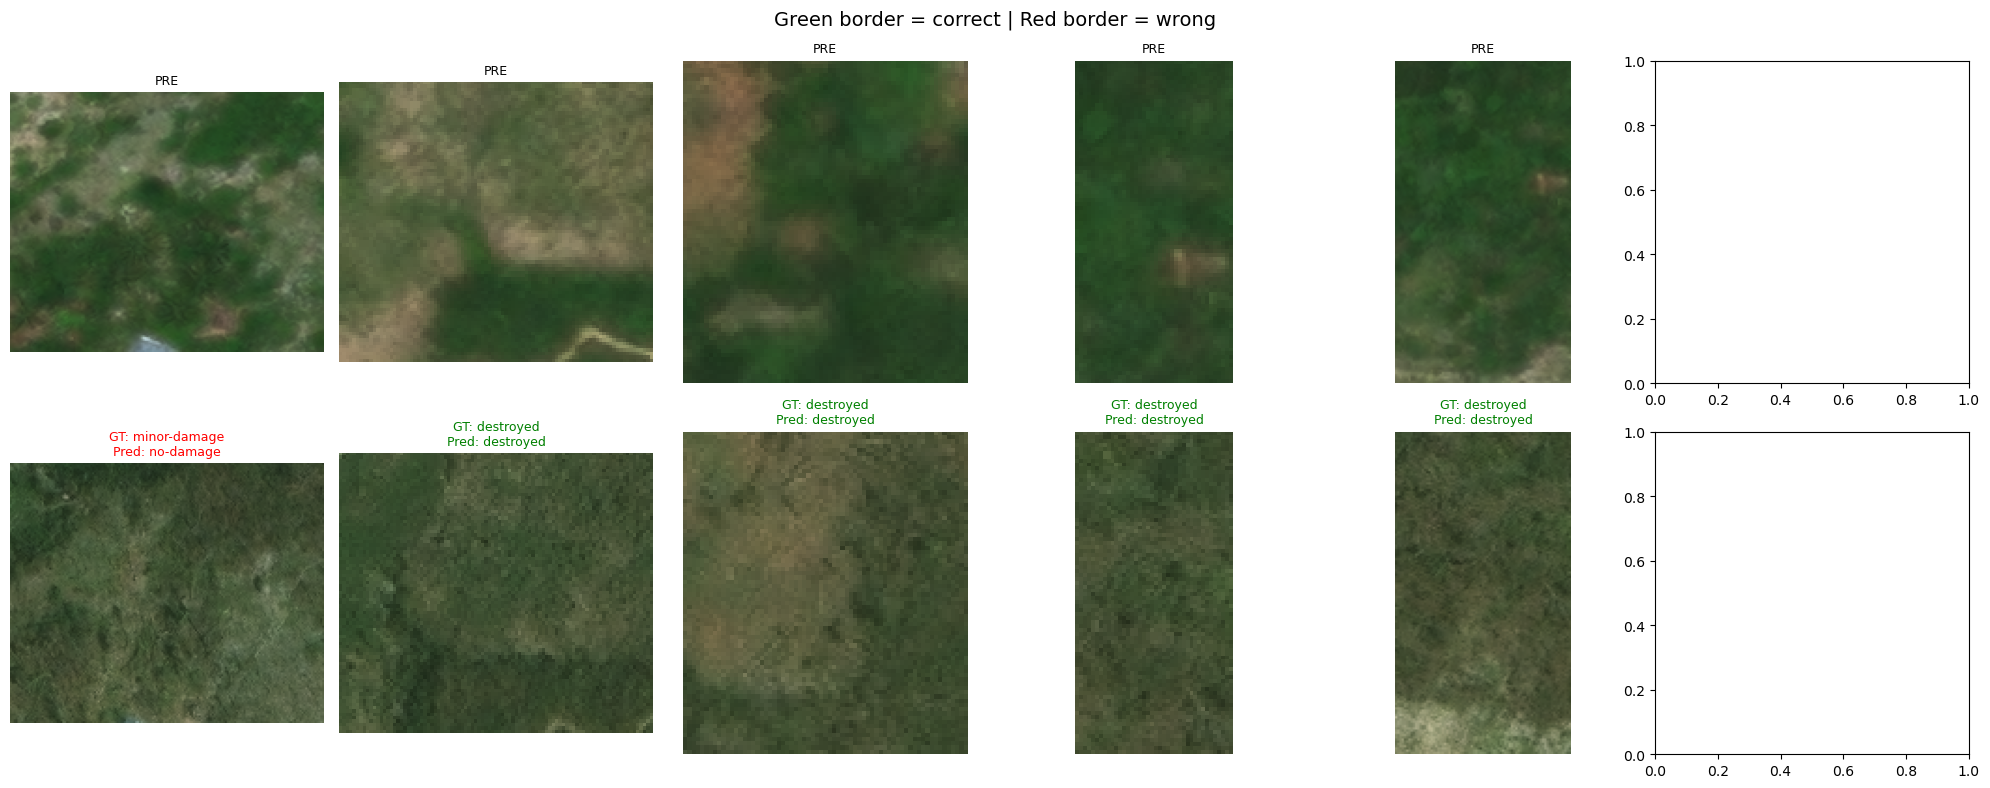

In [21]:
def visualize_predictions(post_img, buildings, results, n=6):
    fig, axes = plt.subplots(2, n, figsize=(20, 8))
    fig.suptitle("Green border = correct | Red border = wrong", fontsize=14)
    
    shown = 0
    for b, r in zip(buildings, results):
        if shown >= n:
            break
        x0, y0, x1, y1 = r["bbox"].astype(int)
        pad = 20
        x0, y0 = max(0, x0-pad), max(0, y0-pad)
        x1, y1 = min(1023, x1+pad), min(1023, y1+pad)
        
        pre_crop  = pre[y0:y1, x0:x1]
        post_crop = post_img[y0:y1, x0:x1]
        
        # get prediction
        pre_t  = transform(Image.fromarray(pre_crop)).unsqueeze(0).to(device)
        post_t = transform(Image.fromarray(post_crop)).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(pre_t, post_t)
        pred = DAMAGE_CLASSES[logits.argmax().item()]
        gt   = b["damage"]
        correct = pred == gt
        
        border_color = "green" if correct else "red"
        
        axes[0, shown].imshow(pre_crop)
        axes[0, shown].set_title(f"PRE", fontsize=9)
        axes[0, shown].axis("off")
        for spine in axes[0, shown].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
        
        axes[1, shown].imshow(post_crop)
        axes[1, shown].set_title(f"GT: {gt}\nPred: {pred}", fontsize=9,
                                  color="green" if correct else "red")
        axes[1, shown].axis("off")
        for spine in axes[1, shown].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
        
        shown += 1
    
    plt.tight_layout()
    plt.show()

visualize_predictions(post, buildings, results)

In [26]:
# point to test directory
TEST_DIR = "/home/sagemaker-user/42028-DLCNN/data/xbd/test"

# build test dataset
test_dataset = XBDDataset(TEST_DIR, predictor)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)
print(f"Test buildings: {len(test_dataset)}")

Found 933 post-disaster label files
Total buildings: 53670
Test buildings: 53670


              precision    recall  f1-score   support

   no-damage       0.97      0.87      0.92     41275
minor-damage       0.46      0.66      0.55      4787
major-damage       0.52      0.68      0.59      3843
   destroyed       0.65      0.84      0.73      3765

    accuracy                           0.83     53670
   macro avg       0.65      0.76      0.70     53670
weighted avg       0.87      0.83      0.85     53670



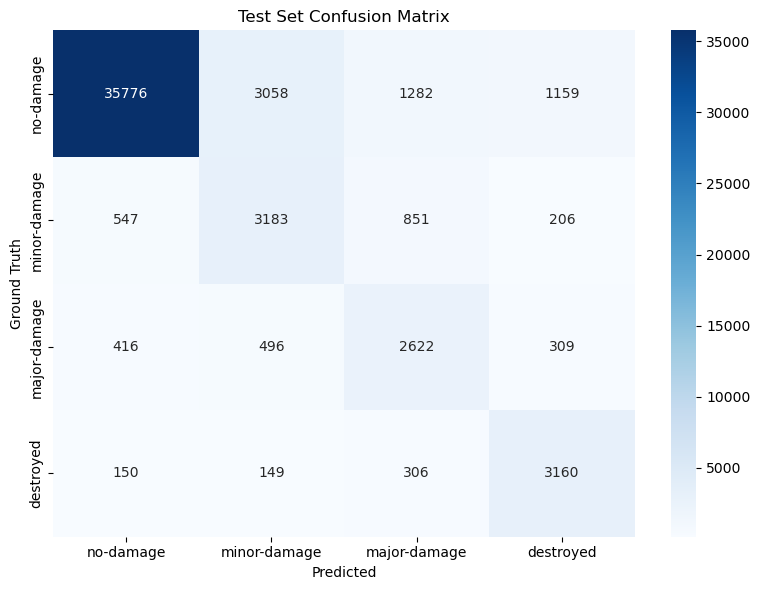

In [23]:
# load best weights
model.load_state_dict(torch.load("/home/sagemaker-user/42028-DLCNN/checkpoints/best_model.pt"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for pre, post, labels in test_loader:
        pre, post = pre.to(device), post.to(device)
        logits = model(pre, post)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# results
print(classification_report(all_labels, all_preds, target_names=DAMAGE_CLASSES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=DAMAGE_CLASSES,
            yticklabels=DAMAGE_CLASSES,
            cmap="Blues")
plt.ylabel("Ground Truth")
plt.xlabel("Predicted")
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [33]:
# find a diverse test sample
TEST_DIR = "/home/sagemaker-user/42028-DLCNN/data/xbd/test"

disaster, sample_id = find_diverse_sample(TEST_DIR)
pre, post, buildings = load_sample(disaster, sample_id, data_dir=TEST_DIR)
print(f"Disaster: {disaster}_{sample_id:08d}")
print(f"Buildings: {len(buildings)}")
for b in buildings:
    print(f"  {b['damage']}")

Found: hurricane-michael_00000378
Damage types: {'major-damage', 'no-damage', 'minor-damage', 'destroyed'}
Disaster: hurricane-michael_00000378
Buildings: 41
  no-damage
  major-damage
  major-damage
  minor-damage
  minor-damage
  no-damage
  no-damage
  no-damage
  minor-damage
  no-damage
  destroyed
  minor-damage
  no-damage
  minor-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  minor-damage
  no-damage
  minor-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  no-damage
  destroyed
  no-damage
  no-damage
  destroyed
  minor-damage


Ground Truth    Predicted       Correct  Confidence IoU   
------------------------------------------------------------
no-damage       minor-damage    ✗        0.875      0.689
major-damage    minor-damage    ✗        0.843      0.592
major-damage    minor-damage    ✗        0.692      0.673
minor-damage    no-damage       ✗        0.585      0.724
minor-damage    minor-damage    ✓        0.983      0.711
no-damage       minor-damage    ✗        0.799      0.723
no-damage       no-damage       ✓        0.409      0.578
no-damage       destroyed       ✗        0.740      0.669
minor-damage    major-damage    ✗        0.533      0.808
no-damage       no-damage       ✓        0.608      0.744
destroyed       major-damage    ✗        0.925      0.749
minor-damage    minor-damage    ✓        0.844      0.764
no-damage       minor-damage    ✗        0.573      0.596
minor-damage    minor-damage    ✓        0.859      0.798
no-damage       no-damage       ✓        0.751      0.846
no-damage 

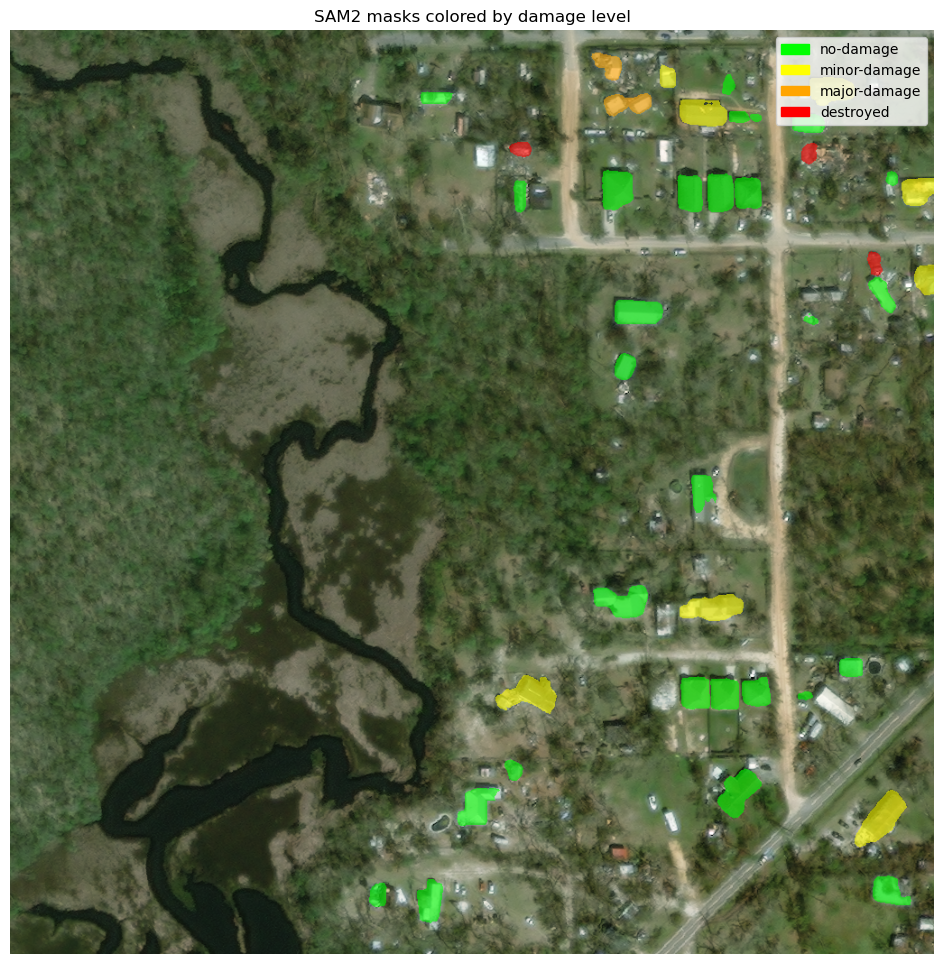

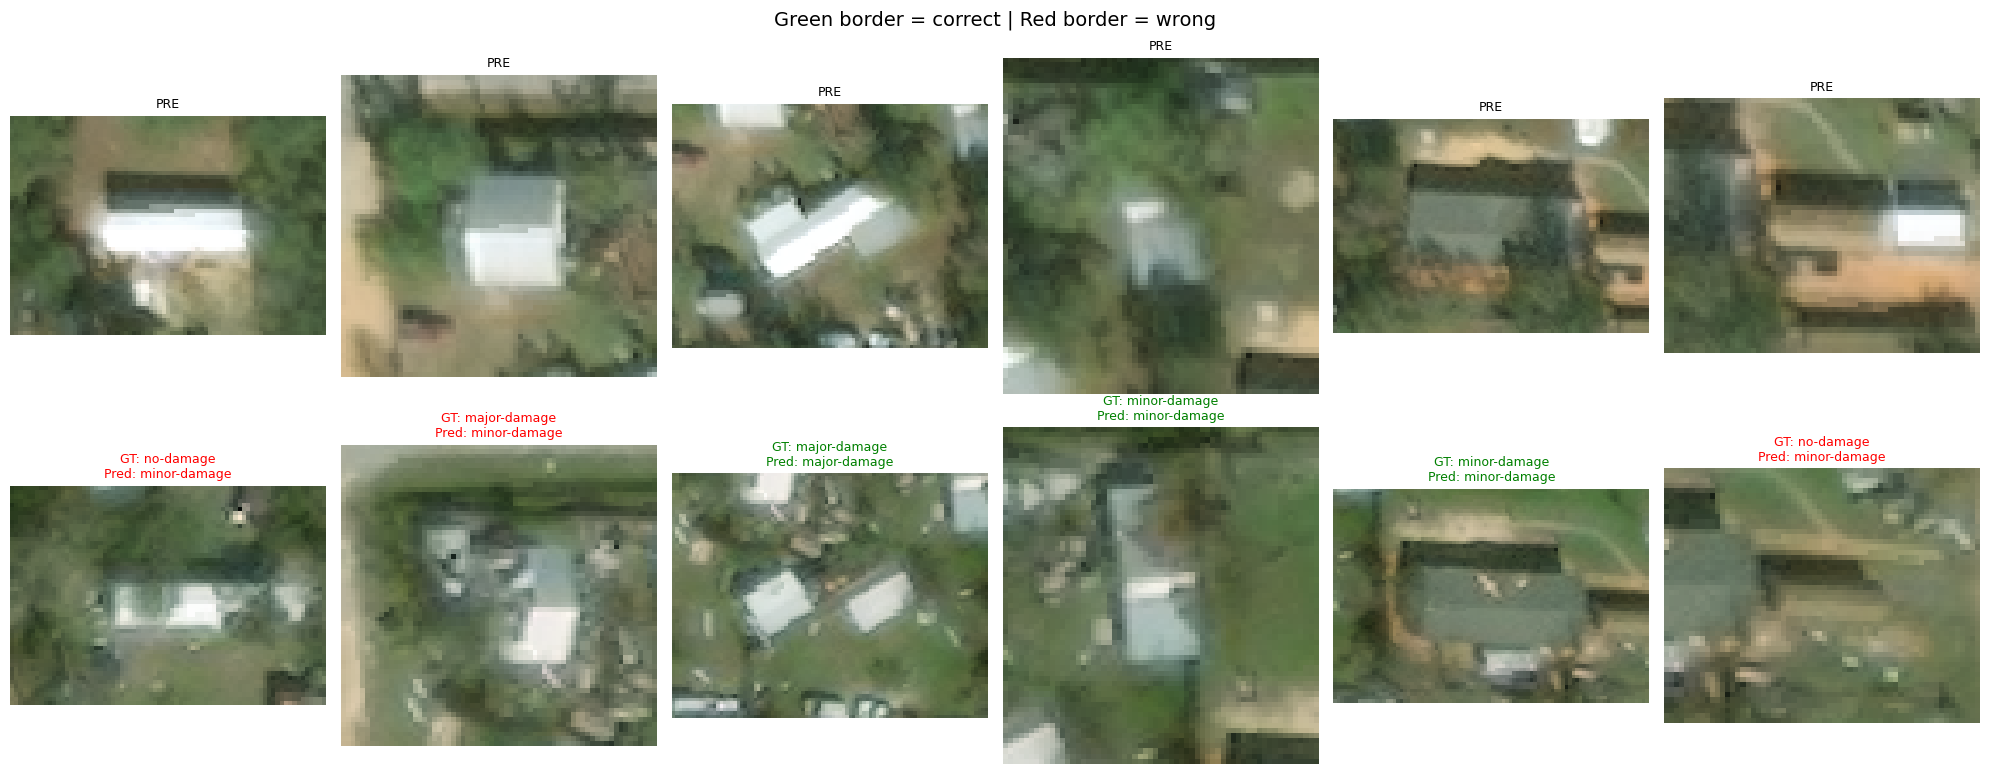

In [35]:
# segment with SAM2 + classify damage
predictor.set_image(post)
model.eval()
results = []

for b in buildings:
    bbox = get_bbox(b["polygon"])
    masks, scores, _ = predictor.predict(box=bbox, multimask_output=False)
    
    # get classifier prediction
    pre_crop  = extract_crop(pre, bbox).unsqueeze(0).to(device)
    post_crop = extract_crop(post, bbox).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(pre_crop, post_crop)
    pred_damage = DAMAGE_CLASSES[logits.argmax().item()]
    confidence  = torch.softmax(logits, dim=1).max().item()
    
    results.append({
        "mask":        masks[0],
        "score":       scores[0],
        "damage":      b["damage"],       # ground truth
        "pred_damage": pred_damage,       # prediction
        "confidence":  confidence,
        "bbox":        bbox,
        "correct":     pred_damage == b["damage"]
    })

# print per-building results
print(f"{'Ground Truth':15s} {'Predicted':15s} {'Correct':8s} {'Confidence':10s} {'IoU':6s}")
print("-" * 60)
sample_ious = []
for b, r in zip(buildings, results):
    gt_mask   = polygon_to_mask(b["polygon"])
    pred_mask = r["mask"].astype(bool)
    iou       = compute_iou(pred_mask, gt_mask)
    sample_ious.append(iou)
    correct_str = "✓" if r["correct"] else "✗"
    print(f"{r['damage']:15s} {r['pred_damage']:15s} {correct_str:8s} {r['confidence']:.3f}      {iou:.3f}")

print(f"\nMean IoU: {np.mean(sample_ious):.3f}")
print(f"Sample accuracy: {sum(r['correct'] for r in results)}/{len(results)}")

# visualize with predictions
visualize_masks(post, results)
visualize_predictions(post, buildings, results)